## About this case study

This was a take-home case for a Pricing Analyst interview, completed under a 2–3 hour timebox. The brief: investigate a complaint that a pricing engine was overpricing high-mileage EVs, using a 43-row sample of pricing requests. It was evaluated on data investigation, root-cause code inspection, and monitoring design, rather than production-scale engineering.

**The dataset and any company/role details have been anonymised or synthesised** for portfolio use; the analysis, code, and findings below are otherwise unedited from the original submission.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('price_engine_requests.csv')

In [3]:
print(df.shape)
print(df.dtypes)


(43, 15)
prediction_id             object
request_date              object
market                    object
model_version             object
guarantee_price_source    object
make                      object
model                     object
model_year                 int64
fuel_type                 object
mileage_km                 int64
power_kw                   int64
guarantee_price_dkk        int64
robot_price_dkk            int64
sold_price_dkk             int64
highest_bid_dkk            int64
dtype: object


In [4]:
display(df)

,prediction_id,request_date,market,model_version,guarantee_price_source,make,model,model_year,fuel_type,mileage_km,power_kw,guarantee_price_dkk,robot_price_dkk,sold_price_dkk,highest_bid_dkk
0,PRED-0001,2026-05-06,DK,m-2026-05,robot,Tesla,Model 3,2021,EV,96000,239,214000,214000,192000,190000
1,PRED-0002,2026-05-07,DK,m-2026-05,robot,Tesla,Model 3,2020,EV,122000,239,198000,198000,170000,168000
2,PRED-0003,2026-05-08,DK,m-2026-05,robot,Tesla,Model Y,2022,EV,88000,378,284000,284000,257000,255000
3,PRED-0004,2026-05-09,DK,m-2026-05,analyst,Polestar,2,2021,EV,94000,300,219000,244000,218000,216000
4,PRED-0005,2026-05-10,DK,m-2026-05,analyst,Volkswagen,ID.4,2021,EV,104000,150,193000,204000,190000,189000
5,PRED-0006,2026-05-11,DK,m-2026-05,analyst,Kia,EV6,2022,EV,83000,168,254000,266000,255000,254000
6,PRED-0007,2026-05-12,DK,m-2026-05,analyst,Nissan,Leaf,2019,EV,115000,110,108000,114000,109000,108000
7,PRED-0008,2026-05-14,DK,m-2026-05,robot,Tesla,Model S,2020,EV,138000,350,263000,263000,229000,226000
8,PRED-0009,2026-05-15,DK,m-2026-05,analyst,BMW,i4,2022,EV,81000,250,294000,307000,296000,295000
9,PRED-0010,2026-05-16,DK,m-2026-05,analyst,Hyundai,Ioniq 5,2022,EV,86000,168,248000,259000,249000,248000


In [5]:
display(df.describe())
print(df.isnull().sum())

,model_year,mileage_km,power_kw,guarantee_price_dkk,robot_price_dkk,sold_price_dkk,highest_bid_dkk
count,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000,43.000000
mean,2021.069767,85720.930233,197.581395,231302.325581,235720.930233,226744.186047,225465.116279
std,1.403997,39781.741194,87.446918,70686.273633,72148.433498,70151.907629,70169.640986
min,2019.000000,19000.000000,90.000000,108000.000000,114000.000000,109000.000000,108000.000000
25%,2020.000000,44000.000000,140.000000,187000.000000,190000.000000,179500.000000,178500.000000
50%,2021.000000,92000.000000,168.000000,239000.000000,244000.000000,230000.000000,227000.000000
75%,2022.000000,116500.000000,250.000000,283000.000000,285000.000000,260000.000000,258500.000000
max,2023.000000,148000.000000,378.000000,377000.000000,382000.000000,377000.000000,376000.000000


prediction_id             0
request_date              0
market                    0
model_version             0
guarantee_price_source    0
make                      0
model                     0
model_year                0
fuel_type                 0
mileage_km                0
power_kw                  0
guarantee_price_dkk       0
robot_price_dkk           0
sold_price_dkk            0
highest_bid_dkk           0
dtype: int64


# Confirmation Phase 

On average across all 43 cars:

Guarantee price: 231,302 DKK
Sold price: 226,744 DKK
Gap: ~4,558 DKK per car on average
but this is the avg on all fuel type so next step would be to go deeper and comfirm that its only EVs

In [6]:
# Fuel Type Distribution (confirming that the dataset is dominated by EVs)

display(df['fuel_type'].value_counts())

fuel_type
EV        29
Diesel     6
Petrol     5
Hybrid     3
Name: count, dtype: int64

In [7]:
# Spread calculation to measure how much the guarantee price exceeds 
# the actual sold price. A positive spread means the platform over-committed (loss), while a negative spread means the platform under-committed (profit but loss of trust).

df['spread'] = df['guarantee_price_dkk'] - df['sold_price_dkk']
df['spread_pct'] = (df['spread'] / df['guarantee_price_dkk']) * 100
display(df[['guarantee_price_dkk', 'sold_price_dkk', 'spread', 'spread_pct']].head())

,guarantee_price_dkk,sold_price_dkk,spread,spread_pct
0,214000,192000,22000,10.280374
1,198000,170000,28000,14.141414
2,284000,257000,27000,9.507042
3,219000,218000,1000,0.456621
4,193000,190000,3000,1.554404


In [8]:
# spread distribution by fuel type
spread_by_fuel = (
    df.groupby('fuel_type')['spread']
    .agg(
        avg_spread_dkk =('mean'),
        total_leakage_dkk=('sum'),
        car_count=('count')
    )
    .reset_index()
    .sort_values(by='avg_spread_dkk', ascending=False))
display(spread_by_fuel)

,fuel_type,avg_spread_dkk,total_leakage_dkk,car_count
1,EV,6655.172414,193000,29
3,Petrol,400.000000,2000,5
0,Diesel,333.333333,2000,6
2,Hybrid,-333.333333,-1000,3


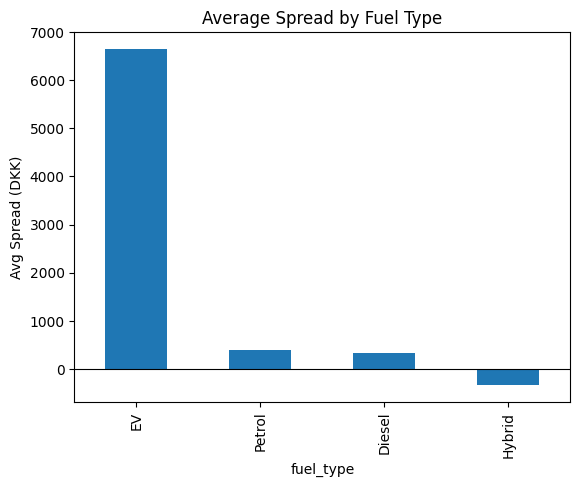

In [9]:
spread_by_fuel.plot(kind='bar', x='fuel_type', y='avg_spread_dkk', legend=False)
plt.title('Average Spread by Fuel Type')
plt.ylabel('Avg Spread (DKK)')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()


As we can see the data confirms that the Evs are predicted high with an avg spread of  6655.17 dkk, while the rest type of fuel spread ranges between -300 and 400 dkk.

# confirm if its only high mileage EVs that are causing the high spread


In [10]:
# identify the healthy threshold for mileage
ev_df = df[df['fuel_type'] == 'EV'].copy()
display(ev_df[['mileage_km', 'spread', 'spread_pct']].describe())


,mileage_km,spread,spread_pct
count,29.000000,29.000000,29.000000
mean,70068.965517,6655.172414,2.674530
std,37745.322354,12652.712476,5.026265
min,19000.000000,-2000.000000,-0.925926
25%,30000.000000,-1000.000000,-0.393701
50%,83000.000000,1000.000000,0.353357
75%,96000.000000,5000.000000,1.809955
max,138000.000000,39000.000000,14.498141


The median is 83000 km and its chosen as cut point, above this threshold is high other than that is low 

In [11]:
# Mileage Band Creation and Spread Comparison


# define mileage threshold

threshold = ev_df['mileage_km'].median() 

# create a new column 'mileage_band' based on the threshold
ev_df['mileage_band'] = np.where(ev_df['mileage_km'] <= threshold, 'Low Mileage', 'High Mileage')

# compare the spread and spread percentage between the two mileage bands
spread_comparison = (
    ev_df.groupby('mileage_band')
    .agg(
        avg_spread_dkk=('spread', 'mean'),
        total_leakage_dkk=('spread', 'sum'),
        car_count=('spread', 'count')
    )
    .reset_index()
    .sort_values(by='avg_spread_dkk', ascending=False))

display(spread_comparison)



,mileage_band,avg_spread_dkk,total_leakage_dkk,car_count
0,High Mileage,13857.142857,194000,14
1,Low Mileage,-66.666667,-1000,15


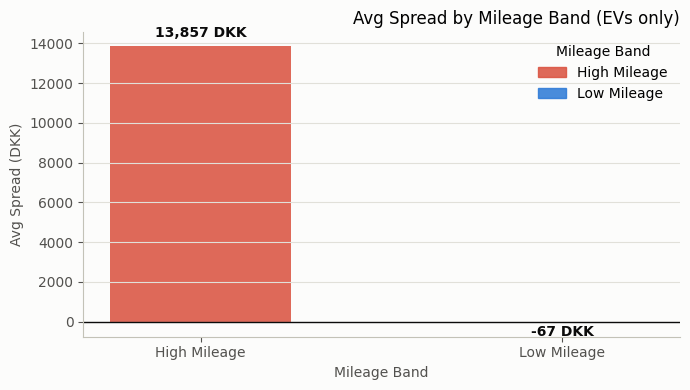

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')

band_colors = {'High Mileage': '#d94f3d', 'Low Mileage': '#2a78d6'}
bands = spread_comparison['mileage_band'].tolist()
values = spread_comparison['avg_spread_dkk'].tolist()
colors = [band_colors[b] for b in bands]

bars = ax.bar(bands, values, color=colors, alpha=0.85, width=0.5)

for bar, val in zip(bars, values):
    y = val + 300 if val >= 0 else val - 800
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'{val:,.0f} DKK', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#0b0b0b')

ax.axhline(0, color='#0b0b0b', linewidth=1)
ax.set_ylabel('Avg Spread (DKK)', color='#52514e')
ax.set_xlabel('Mileage Band', color='#52514e')
ax.set_title('Avg Spread by Mileage Band (EVs only)', loc='right', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#c3c2b7')
ax.tick_params(colors='#52514e')
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)

handles = [plt.Rectangle((0,0),1,1, color=band_colors[b], alpha=0.85) for b in bands]
ax.legend(handles, bands, title='Mileage Band', framealpha=0)

plt.tight_layout()
plt.show()


The hypothesis High mileage EVs are being predicted too high is confirmed by the analysis.

# Investigation Phase - WHY?

In [13]:
# first let's find out which guarantee price source is causing the most leakage for high mileage EV cars
source_comparison = (
    ev_df[ev_df['mileage_band'] == 'High Mileage']
    .groupby('guarantee_price_source')
    .agg(
        avg_spread_dkk=('spread', 'mean'),
        total_leakage_dkk=('spread', 'sum'),
        car_count=('spread', 'count')
    )
    .reset_index()
    .sort_values(by='avg_spread_dkk', ascending=False)
)

display(source_comparison)

,guarantee_price_source,avg_spread_dkk,total_leakage_dkk,car_count
1,robot,30166.666667,181000,6
0,analyst,1625.000000,13000,8


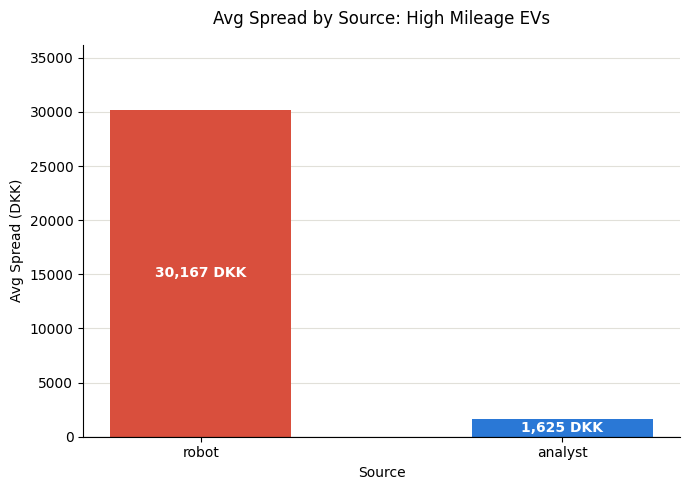

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    source_comparison['guarantee_price_source'],
    source_comparison['avg_spread_dkk'],
    color=['#d94f3d', '#2a78d6'],
    width=0.5
)

for bar in bars:
    val = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val * 0.5,  # place label in the middle of the bar
        f'{val:,.0f} DKK',
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )

ax.set_title('Avg Spread by Source: High Mileage EVs', pad=15)
ax.set_ylabel('Avg Spread (DKK)')
ax.set_xlabel('Source')
ax.set_ylim(0, source_comparison['avg_spread_dkk'].max() * 1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The robot is off by 30,167 DKK per car on high mileage EVs.
The analysts are off by only 1,625 DKK per car, nearly 19x more accurate.
The robot is responsible for 181,000 DKK of the 194,000 DKK total leakage: that's 93% of the damage from only 6 cars.

In [15]:
# check if the overpricing is concentrated in a specific model year for high mileage EVs


model_year_comparison = (
    ev_df[ev_df['mileage_band'] == 'High Mileage']
    .groupby('model_year')
    .agg(
        avg_spread_dkk=('spread', 'mean'),
        total_leakage_dkk=('spread', 'sum'),
        car_count=('spread', 'count')
    )
    .reset_index()
    .sort_values(by='avg_spread_dkk', ascending=False)
)

display(model_year_comparison)

,model_year,avg_spread_dkk,total_leakage_dkk,car_count
1,2020,33666.666667,101000,3
3,2022,14000.000000,56000,4
2,2021,6333.333333,38000,6
0,2019,-1000.000000,-1000,1


In [16]:
make_model_comparison = (
    ev_df[ev_df['mileage_band'] == 'High Mileage']
    .groupby(['make', 'model'])
    .agg(
        avg_spread_dkk=('spread', 'mean'),
        total_leakage_dkk=('spread', 'sum'),
        car_count=('spread', 'count')
    )
    .reset_index()
    .sort_values(by='avg_spread_dkk', ascending=False)
)

display(make_model_comparison)

,make,model,avg_spread_dkk,total_leakage_dkk,car_count
5,Tesla,Model S,36500.000000,73000,2
6,Tesla,Model Y,29000.000000,58000,2
4,Tesla,Model 3,18666.666667,56000,3
3,Polestar,2,2500.000000,5000,2
7,Volkswagen,ID.4,2500.000000,5000,2
0,Hyundai,Ioniq 5,-1000.000000,-1000,1
1,Kia,EV6,-1000.000000,-1000,1
2,Nissan,Leaf,-1000.000000,-1000,1


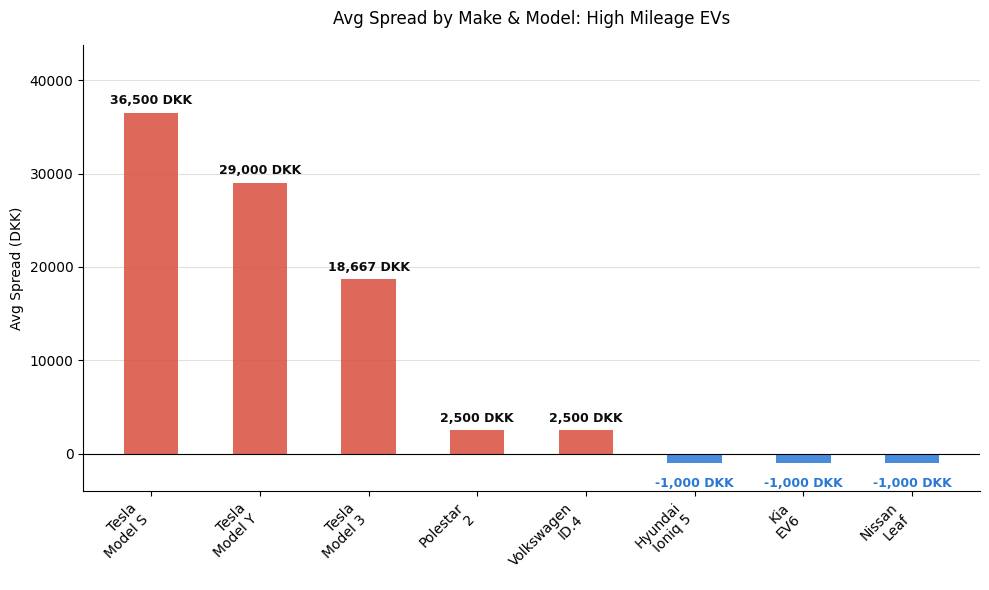

In [17]:

# create make + model label
make_model_comparison['label'] = make_model_comparison['make'] + '\n' + make_model_comparison['model']

fig, ax = plt.subplots(figsize=(10, 6))

labels = make_model_comparison['label'].tolist()
values = make_model_comparison['avg_spread_dkk'].tolist()
colors = ['#d94f3d' if v > 0 else '#2a78d6' for v in values]

bars = ax.bar(labels, values, color=colors, width=0.5, alpha=0.85)

for bar in bars:
    val = bar.get_height()
    if val >= 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 600,
            f'{val:,.0f} DKK',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#0b0b0b'
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            -2500,
            f'{val:,.0f} DKK',
            ha='center', va='top',
            fontsize=9, fontweight='bold', color='#2a78d6'
        )

ax.set_title('Avg Spread by Make & Model: High Mileage EVs', pad=15)
ax.set_ylabel('Avg Spread (DKK)')
ax.set_xlabel('')
ax.set_ylim(-4000, make_model_comparison['avg_spread_dkk'].max() * 1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
model_version_comparison = (
    ev_df[ev_df['mileage_band'] == 'High Mileage']
    .groupby('model_version')
    .agg(
        avg_spread_dkk=('spread', 'mean'),
        total_leakage_dkk=('spread', 'sum'),
        car_count=('spread', 'count')
    )
    .reset_index()
    .sort_values(by='avg_spread_dkk', ascending=False)
)
display(model_version_comparison)

,model_version,avg_spread_dkk,total_leakage_dkk,car_count
0,m-2026-05,14125.0,113000,8
1,m-2026-06,13500.0,81000,6


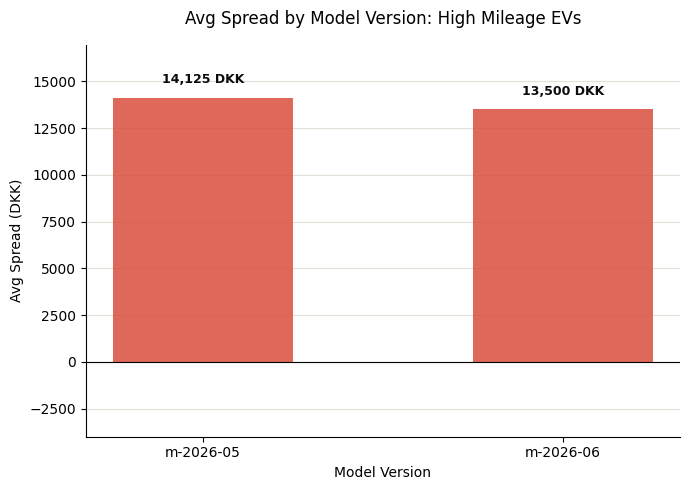

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

versions = model_version_comparison['model_version'].tolist()
values = model_version_comparison['avg_spread_dkk'].tolist()
colors = ['#d94f3d' if v > 0 else '#2a78d6' for v in values]

bars = ax.bar(versions, values, color=colors, width=0.5, alpha=0.85)

for bar in bars:
    val = bar.get_height()
    if val >= 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 600,
            f'{val:,.0f} DKK',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#0b0b0b'
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            -2500,
            f'{val:,.0f} DKK',
            ha='center', va='top',
            fontsize=9, fontweight='bold', color='#2a78d6'
        )

ax.set_title('Avg Spread by Model Version: High Mileage EVs', pad=15)
ax.set_ylabel('Avg Spread (DKK)')
ax.set_xlabel('Model Version')
ax.set_ylim(-4000, model_version_comparison['avg_spread_dkk'].max() * 1.2)
ax.axhline(0, color='black', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Market Dynamics: Guarantee vs Highest Bid

In [20]:
# bid_spread compares the guarantee price to the highest bid received, which tells us about
# market appetite - how aggressively dealers were willing to bid to win the car.
# this is different from spread, which compares the guarantee price to the realised sold price
# and tells us about pricing accuracy and financial exposure instead.

ev_df['bid_spread'] = ev_df['guarantee_price_dkk'] - ev_df['highest_bid_dkk']
ev_df['bid_spread_pct'] = (ev_df['bid_spread'] / ev_df['guarantee_price_dkk']) * 100
display(ev_df[['guarantee_price_dkk', 'highest_bid_dkk', 'bid_spread', 'bid_spread_pct']].head())

,guarantee_price_dkk,highest_bid_dkk,bid_spread,bid_spread_pct
0,214000,190000,24000,11.214953
1,198000,168000,30000,15.151515
2,284000,255000,29000,10.211268
3,219000,216000,3000,1.369863
4,193000,189000,4000,2.072539


Negative bid_spread (guarantee price below highest bid) → strong demand, dealers bid above what we guaranteed, competitive market for that segment.

Positive bid_spread (guarantee price above highest bid) → weak demand, we guaranteed more than the market was willing to pay, no aggressive bidding.

In [21]:
# bid_spread by fuel type
bid_spread_by_fuel = (
    ev_df.groupby('fuel_type')['bid_spread']
    .agg(
        avg_bid_spread_dkk=('mean'),
        total_bid_spread_dkk=('sum'),
        car_count=('count')
    )
    .reset_index()
    .sort_values(by='avg_bid_spread_dkk', ascending=False))
display(bid_spread_by_fuel)

,fuel_type,avg_bid_spread_dkk,total_bid_spread_dkk,car_count
0,EV,8068.965517,234000,29


In [22]:
# bid_spread by mileage band (EVs only)
bid_spread_by_mileage = (
    ev_df.groupby('mileage_band')['bid_spread']
    .agg(
        avg_bid_spread_dkk=('mean'),
        total_bid_spread_dkk=('sum'),
        car_count=('count')
    )
    .reset_index()
    .sort_values(by='avg_bid_spread_dkk', ascending=False))
display(bid_spread_by_mileage)

,mileage_band,avg_bid_spread_dkk,total_bid_spread_dkk,car_count
0,High Mileage,15642.857143,219000,14
1,Low Mileage,1000.000000,15000,15


One thing worth flagging: raw sales volume over time is not a reliable demand signal on its own, because volume also depends on supply (how many cars were listed that period). This dataset doesn't include a listings/supply count, so this is an open question - a proper demand indicator would need bid_spread (or a bids-per-listing ratio) rather than raw counts, precisely because it normalises for market pressure rather than availability.

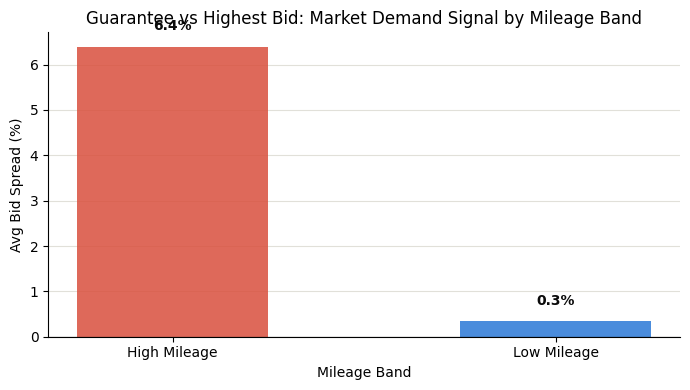

In [23]:
bid_spread_pct_by_mileage = (
    ev_df.groupby('mileage_band')['bid_spread_pct']
    .mean()
    .reset_index()
    .sort_values(by='bid_spread_pct', ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))

band_colors = {'High Mileage': '#d94f3d', 'Low Mileage': '#2a78d6'}
bands = bid_spread_pct_by_mileage['mileage_band'].tolist()
values = bid_spread_pct_by_mileage['bid_spread_pct'].tolist()
colors = [band_colors[b] for b in bands]

bars = ax.bar(bands, values, color=colors, alpha=0.85, width=0.5)

for bar, val in zip(bars, values):
    y = val + 0.3 if val >= 0 else val - 0.8
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#0b0b0b')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Avg Bid Spread (%)')
ax.set_xlabel('Mileage Band')
ax.set_title('Guarantee vs Highest Bid: Market Demand Signal by Mileage Band')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

If bid_spread is small or negative while spread (against sold price) is large and positive, that combination indicates the auction itself had healthy demand: the problem is specifically in how the guarantee price was set, not weak market appetite for these cars.

# Ongoing monitoring 

In [24]:
def monitor_price_engine(df, date_col, metric_col, segment_cols,
                        reference_period, window=26, n_std=2, min_weeks=8):
    """
    Monitors price engine performance using a rolling baseline
    that skips weeks previously flagged as anomalies.

    Parameters:
    - df: DataFrame containing the transaction data.
    - date_col: Column name for the date (e.g. 'request_date').
    - metric_col: Column name for the metric to monitor (e.g. 'spread').
    - segment_cols: List of columns to segment by (e.g. ['market', 'fuel_type', 'mileage_band']).
    - reference_period: Last ISO year-week of the known-good period (e.g. '2026-W21').
    - Weeks up to and including this are trusted as healthy and are not checked.
    - window: Number of weeks to look back when building the baseline (default 26, about 6 months).
    - n_std: Number of standard deviations for the control limits (default 2).
    - min_weeks: Minimum clean weeks required before a segment can be checked (default 8).

    Returns:
    - weekly: every segment week with its average metric and flag status.
    - alerts: only the segment weeks that breached their control band.
    """

   # STEP 1: turn each date into a sortable week label, e.g. '2026-W08'.
    # The year prefix keeps ordering correct across a year boundary, and
    # zfill(2) keeps W08 sorting before W10 when compared as text.
    # Skipped if the column already exists, so the function is safe to rerun.
    if 'year_week' not in df.columns:
        df = df.copy()
        df[date_col] = pd.to_datetime(df[date_col])
        df['year_week'] = (
            df[date_col].dt.isocalendar().year.astype(str) + '-W' +
            df[date_col].dt.isocalendar().week.astype(str).str.zfill(2)
        )

    # one average value per segment per week
    weekly = (
        df.groupby(['year_week'] + segment_cols)[metric_col]
        .mean()
        .reset_index()
    )

    # This column is the memory of the loop: breaches get written here,
    # and future baselines read it to decide what to exclude.
    weekly['flagged'] = False

    # only weeks after the reference period get checked.
    # Sorted oldest first, because each week's baseline depends on
    # flags written during earlier weeks.
    weeks_to_check = sorted(weekly.loc[weekly['year_week'] > reference_period, 'year_week'].unique())

    for week in weeks_to_check:

        #build the reference set for this week:
        # earlier weeks only, limited to the window, and excluding
        # anything already flagged. This is what stops a lasting problem
        # from sliding into its own baseline and silencing the alert.
        past_weeks = sorted(weekly.loc[weekly['year_week'] < week, 'year_week'].unique())
        window_weeks = past_weeks[-window:] 

        baseline = weekly[
            weekly['year_week'].isin(window_weeks) &
            (weekly['flagged'] == False)
        ]

        # band per segment from the clean baseline
        band = (
            baseline
            .groupby(segment_cols)[metric_col]
            .agg(['mean', 'std', 'count'])
            .reset_index()
        )
        band['upper_limit'] = band['mean'] + n_std * band['std']
        band['lower_limit'] = band['mean'] - n_std * band['std']

        # this week's values with the band attached
        this_week = weekly[weekly['year_week'] == week].merge(band, on=segment_cols, how='left')

        # a segment breaches only if it has enough clean weeks behind it
        breached = (
            (this_week['count'] >= min_weeks) &
            ((this_week[metric_col] > this_week['upper_limit']) |
            (this_week[metric_col] < this_week['lower_limit']))
        )

        # write the flags back so future baselines skip these weeks
        breached_segments = this_week.loc[breached, segment_cols]
        for _, seg in breached_segments.iterrows():
            mask = (weekly['year_week'] == week)
            for col in segment_cols:
                mask &= (weekly[col] == seg[col])
            weekly.loc[mask, 'flagged'] = True

    alerts = weekly[weekly['flagged'] == True].reset_index(drop=True)

    return weekly, alerts

This is proposed monitoring logic, not a demonstrated result: it isn't called against this sample. The dataset spans about 7 weeks (2026-05-06 to 2026-06-20), well short of the 26-week rolling window the design assumes, and below the 8-week minimum required before a segment can even start being checked. Running it here would produce an empty or contrived output rather than a real signal. It's included as a specification for how ongoing monitoring would work once enough production history accumulates, to be implemented with the data engineering team.